# 暴叔ai设计

In [1]:
from langgraph.graph import StateGraph, END
from typing import TypedDict, List, Annotated, Literal, Optional
from langchain_core.runnables.graph import MermaidDrawMethod
import nest_asyncio
nest_asyncio.apply()
from langgraph.graph import StateGraph
from pydantic import BaseModel,Field, model_validator
from langgraph.checkpoint.sqlite import SqliteSaver
from langchain_core.messages import SystemMessage, HumanMessage, BaseMessage, AIMessage
import sqlite3
from langchain.chat_models import init_chat_model
from langchain.agents import create_agent
import operator
from IPython.display import Image,display
import requests
import os
from dotenv import load_dotenv, find_dotenv
from enum import Enum
from langgraph.graph.message import add_messages
_ = load_dotenv(find_dotenv())
import re
sf_api_key = os.environ['SF_API_KEY']
bocha_api_key = os.environ['BOCHA_API_KEY']
google_api_key = os.environ['GOOGLE_API_KEY']
deepseek_api_key = os.environ['DEEPSEEK_API_KEY']

qwen3_8B = init_chat_model(
    model = "Qwen/Qwen3-8B",
    model_provider="openai",
    base_url = "https://api.siliconflow.cn/v1",
    api_key = sf_api_key  
)

gemini_flash = init_chat_model(
    model="gemini-2.0-flash",
    model_provider="google_genai",
    api_key = google_api_key
)
#gemini_flash.invoke("hello")

deepseek = init_chat_model(
    model = "deepseek-chat",
    model_provider="deepseek",
    api_key = deepseek_api_key
)
llm = deepseek

#llm.invoke("你好，收到请直接回复1")


## 设计用于表格搜索的数据结构

In [2]:
#核心组件

class BudgetPeriod(str, Enum):
    ANNUAL = "YEAR"       # 每年
    TOTAL = "TOTAL"       # 总共
    UNKNOWN = "UNKNOWN"   # 未说明

class BudgetInfo(BaseModel):
    amount: int = Field(-1, description="预算金额数字(万)，未知填-1")
    period: BudgetPeriod = Field(
        default=BudgetPeriod.UNKNOWN, 
        description="预算周期。如果用户只说了数字没说周期，必须选 UNKNOWN"
    )
class CustomerProfile(BaseModel):
    """客户画像数据结构"""
    #--- 0. 用户角色 ----
    user_role: Optional[Literal["学生", "家长"]] = Field(
        default=None,
        description="""
        判断用户是学生本人还是家长。规则：
        - 出现第一人称("我读高三", "我想去", "我均分") -> '学生'
        - 出现第三人称("孩子高三", "我女儿", "我儿子") -> '家长'
        - 都没出现 -> 'None'
        """
    )
    #--- 1. 当前学历 ----
    educationStage: Optional[Literal["小学","初中","职高","中专", "高中","本科","大专","研究生"]]= Field(
        default=None,
        description="用户【当前】正在读或已毕业的最高学历。注意：不要填用户【想去读】的学历。"
    )
    #--- 2. 留学预算 ----
    budget: BudgetInfo = Field(default_factory=BudgetInfo)
    #--- 3. 出国意向 ----
    destination_preference: Optional[Literal["境外方向","境内/港澳方向"]] = Field(
        default=None,
        description="用户的留学或工作的目的地偏好，'境外方向'代表欧美澳加日韩以及东南亚等海外国家；'境内/港澳方向'代表只考虑香港、澳门、或者内地"
    )
    #--- 4. 学术背景&经历 ----
    academic_background: Optional[str] = Field(
        default = None,
        description="""
        用户的学术背景详情。包括但不限于:
        - 高中生：平时成绩, 排名, 科目偏好
        - 大学生: 专业(Major), 均分（GPA）， 院校层次(985/211/一本/二本/民办)，实习经历，科研经历
        - 专升本： 专科成绩，本科成绩，是否有学位证，实习经历
        - 职高，中专生: 在校成绩，专业，实习经历
        """
    )
    #--- 5. 语言水平 ---
    language_level: Optional[str] = Field(
        default=None,
        description="用户可用于留学的外语能力。包含但不限于：雅思，托福，PTE等英语成绩，日语成绩，韩语Topik成绩，欧洲小语种等"
    )
    
    @property
    def missing_fields(self) -> List[str]:
        missing = []
        if not self.educationStage: missing.append("当前学历")
        elif not self.academic_background: missing.append("学术背景")
        elif self.budget.amount == -1: missing.append("留学预算(数字)")
        elif self.budget.period == BudgetPeriod.UNKNOWN: missing.append("预算周期(每年/总共)")
        elif not self.destination_preference: missing.append("目的地偏好")
        return missing
    @property
    def is_complete(self) -> bool:
        return len(self.missing_fields) == 0
    
# 初始化模型 

extractor_llm = llm.with_structured_output(CustomerProfile)


    

In [3]:
# # --- 测试 Case 1: 正常提取 ---
# print("--- Case 1: 没提预算 ---")
# msg1 = "我是本科生，想去英国，没钱。" # 这种模糊的通常应该也是 -1
# # Gemini Flash 非常聪明，会根据 Schema 逻辑处理
# res1 = extractor_llm.invoke(msg1) # 使用你之前的 test_message
# print(f"结果: {res1}")

# # --- 测试 Case 2: 有预算 ---
# print("\n--- Case 2: 有预算 ---")
# msg2 = "我是211本科，家里准备了50个金币送我出去。"
# res2 = extractor_llm.invoke(msg2)
# print(f"结果: {res2}")
    

# print("--- Case 3: 有预算，但是没提 ---")
# msg3 = "我是本科生，想去美国，家里条件挺好的，预算爸妈给，是够的" # 这种模糊的通常应该也是 -1
# # Gemini Flash 非常聪明，会根据 Schema 逻辑处理
# res3 = extractor_llm.invoke(msg3) # 使用你之前的 test_message
# print(f"结果: {res3}")


# print("--- Case 4: 真实案例 ---")
# test_message = """
# 您好，先介绍一下自己的情况。我是24年西安电子科技大学机械自动化毕业的本科生，
# 平均成绩77.5，绩点3.3，目前在国内液压头部企业干了1.5年研发。
# 我和父母最近在考虑出国留学的事情，父母的想法是这一年准备出国留学，
# 明年合同到期再读1年研究生来重获应届生身份并获得全日制研究生。
# 我关心的是申请的难度，其次就是这一年的含金量，对以后找工作的利弊。我想学机械工程类相关。
# """
# res4 = extractor_llm.invoke(test_message) # 使用你之前的 test_message
# print(f"结果: {res4}")
    

In [4]:
# res4.educationStage

## 设计表格retriever

In [5]:
import pandas as pd

# 1. 加载数据 (全局只加载一次)
try:
    df_db = pd.read_excel("products_intro.xlsx")
    # 预处理：填充空值
    df_db.fillna("", inplace=True)
except Exception as e:
    # 保持原有的容错逻辑
    print(f"⚠️ 警告: 找不到 products_intro.xlsx，将使用空 DataFrame。错误: {e}")
    df_db = pd.DataFrame(columns=["educationStage", "是否出国", "budgetLowerBound", "budgetUpperBound", "annualBudgetLowerBound", "annualBudgetUpperBound", "项目", "项目说明", "项目优势", "画像", "学制"])

def search_products(profile: CustomerProfile) -> str:
    """
    【翻译层 + 检索层】
    将 CustomerProfile 的 'destination_preference' 映射到 Excel 的 '是否出国' 字段
    """
    try:
        # 初始化 Mask (全选)
        mask = pd.Series([True] * len(df_db))
        
        # --- A. 学历筛选 ---
        if profile.educationStage:
            mask &= df_db['educationStage'].str.contains(profile.educationStage, na=False)
            
        # --- B. 意向筛选 (逻辑映射核心修改) ---
        user_pref = profile.destination_preference # "境外方向" / "境内/港澳方向"
        
        if user_pref == "境外方向":
            # 对应原逻辑：包括常规出国 + 缓缓再出国(预科/跳板)
            mask &= df_db['是否出国'].isin(["可以出国", "缓缓再出国"])
            
        elif user_pref == "境内/港澳方向":
            # 对应原逻辑：Excel里的"不要出国"分类 (即港澳/4+0)
            mask &= (df_db['是否出国'] == "不要出国")
            
        # --- C. 预算筛选 (保持不变) ---
        amount = profile.budget.amount
        period = profile.budget.period
        
        if amount > 0: 
            if period == BudgetPeriod.TOTAL:
                mask &= (df_db['budgetLowerBound'] <= amount)
            elif period == BudgetPeriod.ANNUAL:
                mask &= (df_db['annualBudgetLowerBound'] <= amount)
                
        # --- D. 执行筛选 ---
        results = df_db[mask]
        
        # --- E. 格式化输出 ---
        if len(results) == 0:
            return "【系统提示】：数据库中未找到符合该学历和预算的方案。请委婉告知用户目前没有完美匹配的项目，建议调整预算或考虑其他路径。"
            
        output_text = f"共匹配到 {len(results)} 个方案：\n"
        
        for idx, row in results.iterrows():
            proj_name = row.get('项目', '未知项目')
            proj_desc = row.get('项目说明', '')
            proj_adv = row.get('项目优势', '')
            # 这里虽然 Excel 还是叫"是否出国"，但展示给 LLM 时我们可以不强调这个字段，或者保留给它做参考
            proj_type = row.get('是否出国', '') 
            
            total_price = f"{row.get('budgetLowerBound',0)}-{row.get('budgetUpperBound','?')}万"
            annual_price = f"{row.get('annualBudgetLowerBound',0)}-{row.get('annualBudgetUpperBound','?')}万"
            
            output_text += f"""
            --- 方案 {idx+1} ---
            [项目名称]: {proj_name}
            [类型]: {proj_type}
            [预算范围]: 总预算约 {total_price} / 年预算约 {annual_price}
            [项目说明]: {proj_desc}
            [核心优势]: {proj_adv}
            """
            
        return output_text

    except Exception as e:
        return f"【系统错误】：检索过程发生异常: {str(e)}"


/var/folders/vn/_86s7j75565bm1gsklw69jgc0000gn/T/ipykernel_9092/112394616.py:7: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df_db.fillna("", inplace=True)


In [6]:
# test_message = """
# 您好，先介绍一下自己的情况。我是24年西安电子科技大学机械自动化毕业的本科生，
# 平均成绩77.5，绩点3.3，预算50w一年。目前在国内液压头部企业干了1.5年研发。
# 我和父母最近在考虑出国留学的事情，父母的想法是这一年准备出国留学，
# 明年合同到期再读1年研究生来重获应届生身份并获得全日制研究生。
# 我关心的是申请的难度，其次就是这一年的含金量，对以后找工作的利弊。我想学机械工程类相关。
# """
# res4 = extractor_llm.invoke(test_message)
# res4

In [7]:
# search_products(res4)

## Langgraph 组件设计

In [8]:
#Langgraph 核心组件
#Profile Reducer设计
def reduce_profile(old_data: Optional[CustomerProfile], new_data: Optional[CustomerProfile]) -> CustomerProfile:
    """
    工业级合并策略：
    1. 如果新数据是 None，返回旧数据。
    2. 如果旧数据是 None，返回新数据。
    3. 如果两者都有，执行【字段级合并】(Patch Update)。
    """
    # Case 1: 没有新数据，保持原样
    if new_data is None:
        return old_data
    
    # Case 2: 以前没数据，直接用新的
    if old_data is None:
        return new_data

    # Case 3: 新旧都有，执行“非空覆盖” (增量更新)
    # 我们创建一个副本，避免修改原始对象
    merged = old_data.model_copy()
    
    # 逐个字段检查：只有当新数据里有值时，才覆盖旧的
    if new_data.user_role is not None:
        merged.user_role = new_data.user_role
    if new_data.educationStage is not None:
        merged.educationStage = new_data.educationStage
        
    if new_data.destination_preference is not None:
        merged.destination_preference= new_data.destination_preference
        
    if new_data.budget.amount != -1:
        merged.budget.amount = new_data.budget.amount
        
    if new_data.budget.period != BudgetPeriod.UNKNOWN:
        merged.budget.period = new_data.budget.period
    if new_data.academic_background is not None:
        merged.academic_background = new_data.academic_background
        
    if new_data.language_level is not None:
        merged.language_level = new_data.language_level
        
    return merged

class IntentType(str, Enum):
    SALES_READY = "SALES_READY"       # 高意向 -> 拉群
    HIGH_VALUE = "HIGH_VALUE"
    NEED_CONSULTING = "NEED_CONSULTING" # 正常咨询 -> 提取+问询
    GREETING = "GREETING"             # 打招呼 -> 破冰
    CHIT_CHAT = "CHIT_CHAT"           # 闲聊 -> 敷衍

class AgentState(TypedDict):
    messages: Annotated[List[BaseMessage], add_messages]
    profile: Annotated[CustomerProfile,reduce_profile]
    # 增加这个，用于记录是否已经给过初步方案
    # 如果是 True，说明我们进入了“博弈阶段”
    has_proposed_solution: bool 
    dialog_status: Literal["START", "PROFILING", "PERSUADING", "FINISHED"]
    last_intent: Optional[IntentType]

class IntentResult(BaseModel):
    intent: IntentType

def classifier_node(state: AgentState):
    print("--- 🧠 正在给客户分三六九等 ---")
    recent_msg = state["messages"][-6:].content
    current_status = state.get("dialog_status")
    classifier = llm.with_structured_output(IntentResult)
    
    prompt = [
            SystemMessage(content="""
            你是留学顾问暴叔。请根据用户的最新回复判断客户层级和意图
            
            【判定逻辑 - 优先级从高到低】
            1. 💎 **SALES_READY (直接成交)**:
               - 用户已经不再问方案，而是问"怎么交钱"、"怎么签约"、"在哪报名","看合同"。
            2. 🔥 **HIGH_VALUE (高价值/VIP客户)**:
               - **关键词**: 
                 - 预算高: "不差钱", "预算没问题", "50w+", "80w", "100w".
                 - 背景强: "美本", "英本", "澳本", "加本", "海高", "美高", "A-level", "IB".
                 - 目标高: "只想去滕校", "G5", "港三".
               - **逻辑**: 只要用户流露出“不缺钱”或者“出身海外名校”的信号，一律归为此类。
            
            3. 📋 **NEED_CONSULTING (普通咨询)**:
               - 普通背景（双非/211），预算正常或未提及，需要常规规划。
               
            4. 👋 **GREETING / CHIT_CHAT**:
               - 纯打招呼或闲或简单的语气词，且没有包含任何业务信息
            """)
    ] + recent_msg
    res = classifier.invoke(prompt)
    updates = {"last_intent": res.intent}
    
    if res.intent == "HIGH_VALUE":
        updates["dialog_status"] = "VIP_SERVICE"
    
    elif res.intent == "NEED_CONSULTING":
        if current_status != "VIP_SERVICE":
            updates["dialog_status"] = "CONSULTING"
    
    return updates



def high_value_node(state: AgentState):
    print("--- 🎩 High Value: VIP 尊享接待 (真人版) ---")
    
    profile = state.get("profile") or CustomerProfile()
    messages = state["messages"]
    
    # -----------------------------------------------------------
    # 1. 逻辑分流：是该套话(Ask) 还是 该给方案(Propose)?
    # -----------------------------------------------------------
    # 哪怕是 VIP，如果不知道具体 GPA，也没法推“内推”或“豁免”方案。
    # 所以必须先检查有没有“硬数据”。
    
    curr_bg = profile.academic_background or ""
    # 宽松正则：只要有数字、GPA、均分、绩点、等级等词，就认为有底了
    has_score = bool(re.search(r'\d|GPA|均分|绩点|等级|Merit|Distinction|分', curr_bg, re.IGNORECASE))
    
    # 决定当前模式
    mode = "ASK_GPA" if not has_score else "PROPOSE_VIP"
    
    # -----------------------------------------------------------
    # 2. 动态构建 System Prompt
    # -----------------------------------------------------------
    
    system_prompt = f"""
    你是“暴叔”，面对的是一位【VIP高净值客户】（预算充足或背景显赫）。
    
    【客户画像】
    - 身份: {profile.user_role}
    - 背景: {profile.academic_background}
    - 预算: {profile.budget.amount}
    
    【当前模式】: {mode}
    
    【暴叔的人设】
    - 态度：不卑不亢，掌握核心资源的“操盘手”。
    - 风格：拒绝客服腔，拒绝长篇大论，**每条消息严格控制在 30 字以内**。
    - 格式：使用 ||| 分隔消息气泡。
    
    【策略逻辑】
    
    👉 **情况 A (模式=ASK_GPA)：不知道具体成绩**
    - **任务**：先捧后问。默认对方预算充足，礼貌询问 GPA 以确定操作空间。
    - **接话**：如果用户上一句在问问题（如“有推荐吗”），先用一句话敷衍/简单回应。
    - **话术示范**：
      "美本的背景就是金字招牌，申请很有优势！|||
      咱们本科GPA大概多少？透个底，低点也没事，我有路子。"
      
    👉 **情况 B (模式=PROPOSE_VIP)：已知成绩**
    - **任务**：抛出“定制化/内推”方案，吸引拉群。
    - **核心卖点**：强调“内推名额”、“豁免权”、“特殊通道”。**不要走普通网申逻辑**。
    - **话术示范**：
      "这背景走普通网申太亏了，容易被系统误杀。|||
      我手里正好有几个港三的内推名额，能豁免部分GPA限制。|||
      这种走“特殊人才引进”的路子，你想了解吗？"
    """
    
    # 3. 调用 LLM
    response = llm.invoke([SystemMessage(content=system_prompt)] + messages)
    
    # 4. 处理输出
    # 清洗掉可能的 markdown 和多余换行
    raw_content = response.content.replace("\n\n", "\n").replace("**", "")
    split_texts = raw_content.split("|||")
    ai_messages = [AIMessage(content=text.strip()) for text in split_texts if text.strip()]
    
    # 5. 状态流转标记
    # 如果是 PROPOSE_VIP 模式，意味着我们已经抛出了钩子，接下来该 Sales Detector 介入判断用户是否感兴趣了
    has_proposed = (mode == "PROPOSE_VIP")
    
    return {
        "messages": ai_messages, 
        "has_proposed_solution": has_proposed,
        "dialog_status": "VIP_SERVICE"
    }
    
    
def sales_node(state: AgentState):
    print("--- 💎 Sales: 收网 (真人模拟版) ---")
    
    messages = state["messages"]
    last_user_msg = messages[-1].content # 用户上钩的那句话
    profile = state["profile"]
    
    # 简单的逻辑判断，辅助 AI 决定拉什么老师
    specialist_role = "负责这个项目的"
    if profile.destination_preference == "境外方向":
        specialist_role = "专门负责英联邦和美国申请的"
    elif profile.destination_preference == "境内/港澳方向":
        specialist_role = "专门负责国内和港澳申请的"

    system_prompt = f"""
    你就是留学顾问“暴叔”。
    
    【当前局势】
    你之前推荐了学校/项目，用户现在很感兴趣（问细节/问认证/问难度）。
    用户刚才说："{last_user_msg}"
    
    【你的任务】
    用**最像真人**的微信聊天语气，完成“解答+制造稀缺+拉群”的三步走。
    
    【三步走策略】
    1. **给甜头 (Sweetener)**：
       - 用**大白话**快速回答他的核心顾虑。
       - 比如问认证，就说“必须能认，中留服可查”。
       - 比如问难不难，就说“这项目对你来说有机会，但有技巧”。
       
    2. **造门槛 (The Catch)**：
       - **常规留学 (英美澳加)**：强调“文书”、“选校策略”、“往年录取案例”。告诉他这事儿很细，得看具体案例。
       - **特殊项目 (预科/副学士/4+0)**：强调“名额少”、“内部考纲”、“入学门槛”。
       
    3. **转交收网 (Handover)**：
       - 不要说“我给你发”，要说“我拉个群，让**{specialist_role}顾问老师**跟你对接”。
       - 理由：资料在老师那儿，或者老师更懂细节。
    
    【严禁事项 - 必须遵守】
    ❌ **严禁使用任何 Markdown 格式**！不要用 **加粗**，不要用 1. 2. 3. 列表。
    ❌ 不要长篇大论，每段话不超过 40 字。
    ❌ 不要像客服一样客气，要像“懂行的大哥”。
    
    【回复格式】
    使用 ||| 分隔每一条消息。
    
    【真人语感示例】
    (场景：用户问这个学校水不水)
    暴叔：这学校绝对不水，在当地就业很硬的，放心。|||
    不过今年申请的人暴多，文书这块如果不针对性地打磨，很容易被刷下来。|||
    稍等，我拉个群，让专门负责美国申请的老师把去年的录取案例发你看看，你对比下就懂了。
    
    (场景：用户问4+0项目还有名额吗)
    暴叔：名额肯定有，但每年都不多，一般来说都要预定的。|||
    这个项目是有内部入学考试的，只看官网介绍没用，得看考纲。|||
    等一下，我拉个群，让项目负责老师把历年真题和考纲发你一份。
    """
    
    # 生成回复
    response = llm.invoke([SystemMessage(content=system_prompt)] + messages)
    
    # Python 侧处理分段
    raw_content = response.content
    split_texts = raw_content.split("|||")
    
    # 二次清洗：防止 LLM 还是忍不住用了 markdown
    cleaned_texts = [text.replace("**", "").strip() for text in split_texts if text.strip()]
    
    ai_messages = [AIMessage(content=text) for text in cleaned_texts]
    
    return {
        "messages": ai_messages,
        "dialog_status": "FINISHED" 
    }
    
def sales_detector_node(state: AgentState):
    print("--- 🧠 Sales Detector: 客户上钩了吗？ ---")
    
    # 只看最近几轮，节省 token
    recent_msgs = state["messages"]
    
    classifier = llm.with_structured_output(IntentResult)
    prompt = [
        SystemMessage(content="""
        你现在处于销售谈判的关键阶段。AI顾问已经给出了初步建议。
        请分析用户最新的回复，判断意图：
        
        1. SALES_READY (上钩了):
           - 用户问细节（"学校在哪？" "学费多少？"）。
           - 用户表示赞同（"听起来不错" "可以考虑"）。
           - 用户问流程（"怎么申请？"）。
           
        2. NEED_CONSULTING (还有疑虑/没兴趣):
           - 用户反驳或拒绝（"我不去韩国" "太贵了"）。
           - 用户提出新问题（"那欧洲呢？"）。
           - 用户沉默或顾左右而言他。
        """),
    ] + recent_msgs
    
    res = classifier.invoke(prompt)
    return {"last_intent": res.intent}

def extractor_node(state: AgentState):
    print("--- 🕵️ Extractor: 混合更新 (原子覆盖 + 文本合并) ---")
    
    # 1. 读取旧档案
    current_profile = state.get("profile")
    if current_profile is None:
        current_profile = CustomerProfile()
        
   
    
    # 2. 获取上下文
    msgs = state["messages"]
    last_user_msg = msgs[-1].content
    last_ai_msg = msgs[-2].content if len(msgs) > 1 else ""

    # 3. 构造 Prompt (核心修改)
    system_prompt = f"""
    你是留学行业信息提取专家，你的任务是根据对话更新客户画像。
    
    【上下文信息】
    1. 上文 AI 问: "{last_ai_msg}"
    2. 当前 用户 答: "{last_user_msg}"
    
    
    【提取规则（优先级由高到低）】
    1. **显式提取 (Explicit)**: 
       - 如果 User 直接陈述了数据（如"预算50万"、"我想去美国"），以用户原话为准，绝对优先。
       
    2. **隐式确认 (Implicit)**:
       - 如果 AI 上文给出了具体信息，User 表达了同意（"没问题"、"可以"），请直接提取 AI 提供的数值。
       
    3. **逻辑推理 (Inference)**: 
       - **当且仅当**用户没有提供上述两条信息时，利用你的常识进行推理补全。
       - **推理场景**:
         - **预算**: 对于已经在海外读书的用户，根据国家地区合理推理预算（如英国高中，70w/年, 美国高中 90w/年，日本高中 20w/年 等等）
         - **目的地**: 根据用户当前所在地，就读院校所在地或意向国家进行合理推断。
    
    【特殊判断】
    - 区分现状与意向："想读本科"是意向(educationStage=None)，"我是大三"是现状(educationStage=本科)。
    - 判断身份：主语是"我"->学生；主语是"孩子/儿子"->家长；不包含主语-> None
    
    如果某字段既无显示信息，也无法逻辑推理，请返回None
    """
    
    # 4. 调用 LLM
    # 我们依然只传 prompt，不需要把整个 profile 对象传进去，避免干扰
    messages = [SystemMessage(content=system_prompt)]
    
    extractor = llm.with_structured_output(CustomerProfile)
    new_data = extractor.invoke(messages)
    
    # 5. Python 守门员逻辑 (The Gatekeeper)
    final_profile = current_profile.model_copy()
    
    # --- 逻辑 A：普通字段 (非空覆盖) ---
    if new_data.user_role is not None:
        final_profile.user_role = new_data.user_role
    if new_data.educationStage is not None:
        final_profile.educationStage = new_data.educationStage
    if new_data.destination_preference is not None:
        final_profile.destination_preference = new_data.destination_preference
    if new_data.budget.amount != -1:
        final_profile.budget.amount = new_data.budget.amount
    if new_data.budget.period != BudgetPeriod.UNKNOWN:
        final_profile.budget.period = new_data.budget.period
        
    if new_data.academic_background:
        if final_profile.academic_background:
            # 如果原来有，就拼在后面
            final_profile.academic_background += f"；{new_data.academic_background}"
        else:
            # 如果原来没有，直接赋值
            final_profile.academic_background = new_data.academic_background

    print(f"最终画像: {final_profile.model_dump_json(exclude_none=True)}")

    return {"profile": final_profile}


def interviewer_node(state: AgentState):
    print("--- 👩‍💼 Interviewer: 暴叔 (DeepSeek V3 自由发挥版) ---")
    
    profile = state.get("profile") or CustomerProfile()
    missing = profile.missing_fields
    # 获取上下文
    user_role = profile.user_role      # "学生" / "家长"
    stage = profile.educationStage     # "高中" / "本科" ...
    if not missing:
        return {"messages": [AIMessage(content="情况都清楚了，咱们直接看方案！")]}
    
    target_field = missing[0]
    
    curr_bg = profile.academic_background or ""
    has_score_info = bool(re.search(r'\d|GPA|均分|绩点|分数|及格|挂科', curr_bg, re.IGNORECASE))
    
    if not has_score_info:
        target_field= "academic_background"
        force_ask_score = True
    else:
        force_ask_score = False
    if not target_field and has_score_info:
        return {"messages": [AIMessage(content="情况都摸透了，这就给你出方案！")]}
    
    
    # ============================================================
    # 1. 动态人设 (Role Persona) - 决定语气
    # ============================================================
    # 这部分保持不变，因为它决定了“屁股坐在哪一边”
    if user_role == "家长":
        role_instruction = "【对话策略】：对方是家长。语气要稳重、让其放心。关注点在于安全、就业，孩子前途。"
    elif user_role == "学生":
        role_instruction = "【对话策略】：对方是学生。语气要像老大哥一样懂行、给鼓励。关注点在于学校排名。"
    else:
        role_instruction = "【对话策略】：身份未知。默认当做学生聊，保持中性亲切。"

    # ============================================================
    # 2. 动态关注点 (Focus Points) - 决定问什么方向
    # ============================================================
    # 这里的关键是：只给方向，不给具体句子！
    
    focus_instruction = ""
    
    if target_field == "academic_background":
        lang_status = "（顺便问一下雅思/托福等**语言准备情况**）" if not profile.language_level else ""
        
        if force_ask_score:
            focus_instruction = f"【重点追问】：用户虽然提了背景，但**没给硬性成绩**！请务必礼貌地追问：**GPA、均分、或大概成绩段**是多少？这是必须知道的。{lang_status}"
        elif stage == "高中":
            focus_instruction = f"【关注点】：平时成绩/排名、偏科情况、{lang_status}。"
        elif stage in ["本科", "大专"]:
            focus_instruction = f"【关注点】：就读专业、院校层次(双非/211)、**均分/GPA**、{lang_status}。"
        else:
            focus_instruction = f"【关注点】：目前的在读学校、**成绩水平**、{lang_status}。"
            
    elif target_field == "budget":
        focus_instruction = "【关注点】：家庭支持的**留学预算范围**（确认是一年还是总预算）。"
        
    elif target_field == "destination_preference":
        focus_instruction = "【关注点】：**目的地偏好**。是倾向去**境外**（英美澳加日韩）闯一闯，还是**境内/港澳**求稳？"

    # ============================================================
    # 3. 强制打招呼 (Greeting) - 保持不变
    # ============================================================
    greeting_instruction = ""
    if user_role:
        target_greeting = f"{'同学' if user_role == '学生' else '家长'}您好！"
        has_greeted = False
        for msg in state["messages"]:
            if isinstance(msg, AIMessage) and target_greeting in msg.content:
                has_greeted = True; break
        if not has_greeted:
            greeting_instruction = f"**回复必须以 “{target_greeting}” 开头**。"

    # ============================================================
    # 4. 组装极简 Prompt
    # ============================================================
    
    system_prompt = f"""
    你就是留学顾问“暴叔”。
    
    【已知画像】: {profile.model_dump_json(exclude_none=True)}
    【当前任务】: 追问缺失项 -> **{target_field}**
    
    {greeting_instruction}
    
    {role_instruction}
    {focus_instruction}
    
    
    【暴叔的聊天规范】
    1. **拒绝废话**：直奔主题，简单回应用户上一句，并简练抛出新问题，每段话不许超过30字
    2. **懂行**：说话要切中要害，对数据敏感。如果问成绩，表现出对分数敏感；如果问预算，表现出对性价比关注
    3. **接话艺术**:如果用户上一句是在问问题，你必须用一句话简单回应，可以用自己的知识库回答，然后自然衔接问题
    4. **自然分段**： 在【回应客户】和【抛出新问题】之间 使用"|||" 分隔
    """

    # 调用
    messages = [SystemMessage(content=system_prompt)] + state["messages"]
    response = llm.invoke(messages) # 这里推荐用 DeepSeek
    
    # Split处理
    raw_content = response.content.replace("\n\n", "\n")
    split_texts = raw_content.split("|||")
    ai_messages = [AIMessage(content=text.strip()) for text in split_texts if text.strip()]
    
    return {"messages": ai_messages}

def consultant_node(state: AgentState):
    print("--- 🎓 Consultant: 专家诊断 (DeepSeek V3版) ---")
    
    profile = state["profile"]
    intent = state.get("last_intent")
    
    # 1. 检索方案
    retrieved_context = search_products(profile)
    
    # 2. 构建 Prompt：引入“差距分析”逻辑
    system_prompt = f"""
    你就是留学顾问“暴叔”。
    
    【客户背景】
    - 身份: {profile.user_role}
    - 学历: {profile.educationStage}
    - 学术/语言: {profile.academic_background} (这是核心硬通货)
    - 预算: {profile.budget.amount}万 （重要指标）
    - 地区偏好: {profile.destination_preference}
    
    【数据库方案参考】
    {retrieved_context}
    
    【你的任务】
    基于用户的【学术背景】+【预算】，结合方案池，给出一个专家级的初步诊断方案
    
     【风格强制要求 - 必须严格遵守】
    1. **像真人一样说话**：不要用"首先、其次、综上所述"。不要写小作文！
    2. **字数限制**：**总字数不要超过 80 字**。越短越好。
    3. **直给结论**：直接丢出 1-2 个最匹配的学校/项目名称（基于数据库或你的知识库）。
    4. **结尾给用户问题, 吸引用户回复**
    
    【完美回答范例 (请模仿这个语气)】
    "同学，你这个背景去美国转码挺稳的。|||
    建议重点考虑南加大CS37或者是东北大学的Align CS。|||
    这两个项目专收转专业的，你感兴趣吗？"
       
     【输出格式与风格】
     每段话用 ||| 分段。这些段落将作为单独的微信消息发送给客户。风格要自信笃定
    """
    
    messages = [SystemMessage(content=system_prompt)] + state["messages"]
    response = llm.invoke(messages) 
    
    # split 处理
    split_texts = response.content.split("|||")
    ai_messages = [AIMessage(content=text.strip()) for text in split_texts if text.strip()]
    
    return {"messages": ai_messages, "has_proposed_solution": True, "dialog_status": "PERSUADING"}

In [9]:
# #测试classifier
# test_message = """
# 您好，先介绍一下自己的情况。我是24年西安电子科技大学机械自动化毕业的本科生，
# 平均成绩77.5，绩点3.3，目前在国内液压头部企业干了1.5年研发。
# 我和父母最近在考虑出国留学的事情，父母的想法是这一年准备出国留学，
# 明年合同到期再读1年研究生来重获应届生身份并获得全日制研究生。
# 我关心的是申请的难度，其次就是这一年的含金量，对以后找工作的利弊。我想学机械工程类相关。
# """
# messages = test_message
# classifier = llm.with_structured_output(IntentResult)
# prompt = [
#         SystemMessage(content="""
#         你是留学顾问暴叔。判断用户意图。
        
#         定义：
#         - SALES_READY: 用户背景完整，且有相当明确的主流国家（英美澳加，港澳日）的出国意向
#         - NEED_CONSULTING: 用户背景缺失严重，出国意向模糊，或者非常担心焦虑
#         - GREETING: 你好/在吗。
#         - CHIT_CHAT: 无关话题。
#         """),
#         HumanMessage(content=test_message)             
# ]
    
# res = classifier.invoke(prompt)
# res

## Langgraph 组装画图

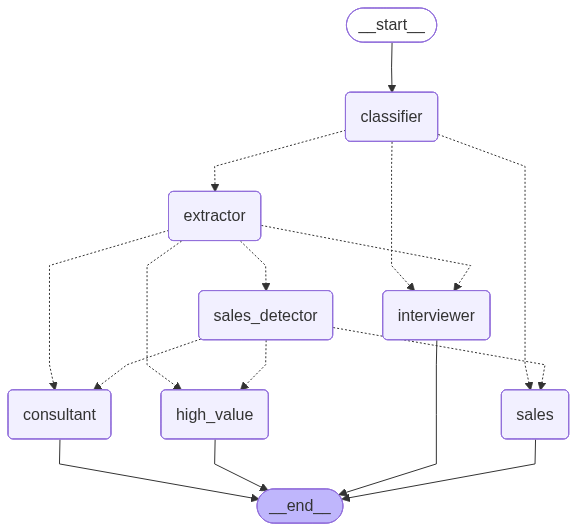

In [11]:
# ==========================================
# 1. 定义路由逻辑 (The Brains)
# ==========================================
from langgraph.checkpoint.memory import MemorySaver
def route_entry(state: AgentState):
    """
    【全时段雷达入口】
    不管上一轮聊到哪，每一句新话都必须先过 Classifier。
    这样才能随时捕捉 "不想聊了"、"我要签约" 或 "我是隐形富豪" 的信号。
    """
    return "classifier"

def route_classifier(state: AgentState):
    """
    【初筛分流】
    Classifier 跑完后，根据意图分发。
    """
    intent = state.get("last_intent")
    status = state.get("dialog_status")
    
    # 1. 极其罕见的直接成交 -> Sales
    if intent == IntentType.SALES_READY:
        return "sales"
    
    # 2. 纯闲聊/打招呼 -> Interviewer (省去Extractor的Token，让Interviewer陪聊)
    if intent == IntentType.GREETING and status == "START":
        return "interviewer"
        
    # 3. 其他所有情况 (VIP / 普通咨询 / 咨询中途) -> 统统去 Extractor
    # 为什么 VIP 也要去 Extractor？
    # 因为 VIP 刚才说的 "我预算800w" 需要被 Extractor 存进 Profile 里！
    # 存完之后，route_extractor 会负责把它导向 high_value_node
    return "extractor"

def route_extractor(state: AgentState):
    """
    【中枢路由】
    Extractor 更新完画像后，决定下一步去哪。
    这里是 VIP 轨道和普通轨道的分岔口。
    """
    profile = state["profile"]
    status = state.get("dialog_status")
    has_proposed = state.get("has_proposed_solution", False)
    
    # ==========================
    # 🚀 VIP 快速通道
    # ==========================
    if status == "VIP_SERVICE":
        # 如果已经给过 VIP 方案 -> 去博弈检测
        if has_proposed:
            return "sales_detector"
        # 否则 -> 继续在 VIP 节点接待 (套话/给方案)
        else:
            return "high_value"
            
    # ==========================
    # 🐢 普通咨询通道
    # ==========================
    
    # 1. 画像还不全 -> Interviewer 追问
    # (注意：我们在 interviewer 内部加了更严格的门禁，这里主要靠 Pydantic 判断)
    if not profile.is_complete:
        return "interviewer"
    
    # 2. 画像齐了，还没给方案 -> Consultant 专家诊断
    if not has_proposed:
        return "consultant"
    
    # 3. 方案给过了 -> Sales Detector 博弈分析
    return "sales_detector"

def route_sales_detector(state: AgentState):
    """
    【博弈路由】
    Detector 分析完用户对方案的反应后...
    """
    intent = state.get("last_intent")
    status = state.get("dialog_status")
    
    # 1. 上钩了 -> 收网
    if intent == IntentType.SALES_READY:
        return "sales"
        
    # 2. 还有疑虑 / 没反应过来 -> 回去继续聊
    else:
        # 如果是 VIP 客户 -> 回 VIP 接待室继续哄
        if status == "VIP_SERVICE":
            return "high_value"
        # 如果是普通客户 -> 回 Consultant 继续解释
        else:
            return "consultant"
        


# ==========================================
# 2. 组装图 (The Architecture)
# ==========================================

workflow = StateGraph(AgentState)

# --- 添加所有节点 ---
workflow.add_node("classifier", classifier_node)
workflow.add_node("extractor", extractor_node)

workflow.add_node("interviewer", interviewer_node)
workflow.add_node("consultant", consultant_node)
workflow.add_node("high_value", high_value_node)  # 🔥 新增 VIP 节点
workflow.add_node("sales_detector", sales_detector_node)
workflow.add_node("sales", sales_node)

# --- 设置入口 (永远是 Classifier) ---
workflow.set_entry_point("classifier")

# --- 连接 Classifier (分流) ---
workflow.add_conditional_edges(
    "classifier",
    route_classifier,
    {
        "sales": "sales",
        "interviewer": "interviewer",
        "extractor": "extractor"
    }
)

# --- 连接 Extractor (中枢) ---
workflow.add_conditional_edges(
    "extractor",
    route_extractor,
    {
        "high_value": "high_value",     # VIP 走这条
        "interviewer": "interviewer",   # 缺信息走这条
        "consultant": "consultant",     # 给方案走这条
        "sales_detector": "sales_detector" # 谈判走这条
    }
)

# --- 连接 Sales Detector (博弈) ---
workflow.add_conditional_edges(
    "sales_detector",
    route_sales_detector,
    {
        "sales": "sales",
        "high_value": "high_value",   # VIP 回炉
        "consultant": "consultant"    # 普通 回炉
    }
)

# --- 设置终点 ---
# 只有这些“说话”的节点才通向 END (等待用户输入)
workflow.add_edge("interviewer", END)
workflow.add_edge("consultant", END)
workflow.add_edge("high_value", END)
workflow.add_edge("sales", END)

# ==========================================
# 3. 编译
# ==========================================
memory = MemorySaver()
app = workflow.compile(checkpointer=memory)

# 画图验证
from IPython.display import Image, display
display(Image(app.get_graph(xray=True).draw_mermaid_png(draw_method=MermaidDrawMethod.API)))


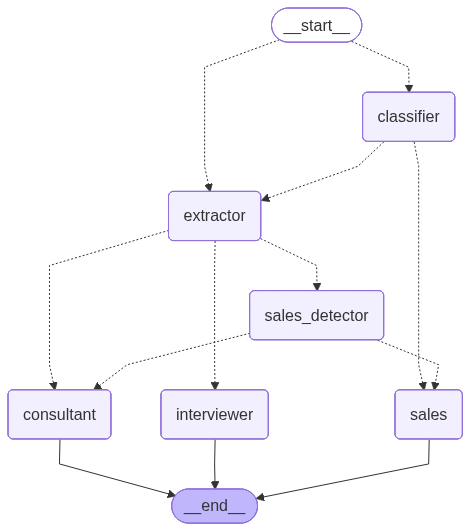

In [ ]:
# #Langgraph 图表架构
# from langgraph.checkpoint.memory import MemorySaver

# # ==========================================
# # 1. 定义路由逻辑 (The Brains)
# # ==========================================

# def route_entry(state: AgentState):
#     """
#     【入口路由】
#     决定是进行“初始分诊”，还是直接进入“咨询流程”。
#     """
#     status = state.get("dialog_status", "START")
    
#     # 如果是 START 或 FINISHED（上一轮聊完了，新开启一轮），先过 Classifier
#     if status in ["START", "FINISHED"]:
#         return "classifier"
    
#     # 如果已经在 PROFILING (填表) 或 PERSUADING (博弈) 阶段，
#     # 直接去 Extractor 更新信息，跳过初始 Classifier 以节省 Token
#     else:
#         return "extractor"

# def route_classifier(state: AgentState):
#     """
#     【初筛路由】
#     Classifier 跑完后，看是不是天选之子（直接成交）。
#     """
#     intent = state.get("last_intent")
    
#     if intent == IntentType.SALES_READY:
#         return "sales" # 极其罕见，但存在（比如用户上来就喊“我要签约”）
#     else:
#         return "extractor" # 其他情况统统去查户口

# def route_extractor(state: AgentState):
#     """
#     【中枢路由】
#     Extractor 更新完画像后，决定下一步去哪。
#     这是最复杂的逻辑节点。
#     """
#     profile = state["profile"]
#     has_proposed = state.get("has_proposed_solution", False)
    
#     # 情况 1: 画像还不全 -> 只能去 Interviewer 追问
#     if not profile.is_complete:
#         return "interviewer"
    
#     # 情况 2: 画像齐了，但还没给过 Consultant 方案 -> 第一次 Consultant
#     if not has_proposed:
#         return "consultant"
    
#     # 情况 3: 画像齐了，且已经给过方案 -> 进入【博弈/谈判阶段】
#     # 此时用户发的消息，是对我们方案的反馈，必须用 Detector 分析
#     return "sales_detector"

# def route_sales_detector(state: AgentState):
#     """
#     【博弈路由】
#     Detector 分析完用户对方案的反应后...
#     """
#     intent = state.get("last_intent")
    
#     if intent == IntentType.SALES_READY:
#         return "sales" # 上钩了 -> 收网
#     else:
#         return "consultant" # 还有疑虑 -> 让专家解释/换方案

# # ==========================================
# # 2. 组装图 (The Architecture)
# # ==========================================

# workflow = StateGraph(AgentState)

# # --- 添加所有节点 ---
# workflow.add_node("classifier", classifier_node)
# workflow.add_node("extractor", extractor_node)
# workflow.add_node("interviewer", interviewer_node)
# workflow.add_node("consultant", consultant_node)
# workflow.add_node("sales_detector", sales_detector_node)
# workflow.add_node("sales", sales_node)

# # --- 设置入口 ---
# workflow.set_conditional_entry_point(
#     route_entry,
#     {
#         "classifier": "classifier",
#         "extractor": "extractor"
#     }
# )

# # --- 连接 Classifier ---
# workflow.add_conditional_edges(
#     "classifier",
#     route_classifier,
#     {
#         "sales": "sales",
#         "extractor": "extractor"
#     }
# )

# # --- 连接 Extractor ---
# workflow.add_conditional_edges(
#     "extractor",
#     route_extractor,
#     {
#         "interviewer": "interviewer",
#         "consultant": "consultant",
#         "sales_detector": "sales_detector"
#     }
# )

# # --- 连接 Sales Detector ---
# workflow.add_conditional_edges(
#     "sales_detector",
#     route_sales_detector,
#     {
#         "sales": "sales",
#         "consultant": "consultant"
#     }
# )

# # --- 设置终点 ---
# # 这些节点跑完后，本轮对话暂停，等待用户输入
# workflow.add_edge("interviewer", END)
# workflow.add_edge("consultant", END)
# workflow.add_edge("sales", END)

# # ==========================================
# # 3. 编译 (Compile)
# # ==========================================
# memory = MemorySaver()
# app = workflow.compile(checkpointer=memory)
# from IPython.display import Image, display
# display(Image(app.get_graph(xray=True).draw_mermaid_png(draw_method=MermaidDrawMethod.API)))

## 本地测试

In [12]:
import ipywidgets as widgets
from IPython.display import display, HTML, Javascript
import uuid
import json
from datetime import datetime
from langchain_core.messages import HumanMessage, AIMessage

# ==========================================
# 1. 样式定义 (CSS) 
# ==========================================
# 关键修改：
# 1. 移除了 .chat-messages 的 flex 定义，因为 Output 组件内部结构较复杂
# 2. 确保 .scrollable-container 拥有滚动属性
style = """
<style>
    /* 主容器 */
    .dashboard-container {
        display: flex;
        gap: 20px;
        width: 100%;
        height: 600px;
        font-family: 'Helvetica Neue', Helvetica, Arial, sans-serif;
    }
    
    /* 左侧：聊天窗口外壳 */
    .chat-panel {
        flex: 1;
        border: 1px solid #e0e0e0;
        border-radius: 12px;
        background-color: #f5f5f5;
        display: flex;
        flex-direction: column;
        overflow: hidden;
    }
    .chat-header {
        padding: 15px;
        background-color: #ededed;
        border-bottom: 1px solid #dcdcdc;
        font-weight: bold;
        color: #333;
        flex-shrink: 0; /* 防止头被压扁 */
    }
    
    /* 核心：滚动容器 (绑定到 Output widget) */
    .scrollable-container {
        flex: 1;
        overflow-y: auto !important; /* 强制开启滚动 */
        padding: 15px;
        scroll-behavior: smooth; /* 平滑滚动 */
        display: block; /* 覆盖默认 flex */
    }

    /* 消息气泡 */
    .msg-row {
        display: flex;
        width: 100%;
        margin-bottom: 15px; /* 增加间距 */
    }
    .msg-row.user { justify-content: flex-end; }
    .msg-row.ai { justify-content: flex-start; }
    
    .bubble {
        max-width: 80%;
        padding: 10px 14px;
        border-radius: 8px;
        font-size: 14px;
        line-height: 1.5;
        position: relative;
        word-wrap: break-word;
    }
    .bubble.user { background-color: #95ec69; color: #000; }
    .bubble.ai { background-color: #ffffff; border: 1px solid #e0e0e0; color: #000; }
    
    .avatar {
        width: 30px; height: 30px; border-radius: 4px; margin: 0 10px;
        display: flex; align-items: center; justify-content: center;
        font-size: 12px; color: white; font-weight: bold;
        flex-shrink: 0;
    }
    .avatar.user { background-color: #1aad19; }
    .avatar.ai { background-color: #2c3e50; }

    /* 右侧：日志面板 */
    .log-panel {
        flex: 1;
        border: 1px solid #333;
        border-radius: 12px;
        background-color: #1e1e1e;
        color: #00ff00;
        font-family: 'Consolas', 'Monaco', monospace;
        font-size: 12px;
        display: flex;
        flex-direction: column;
        overflow: hidden;
    }
    .log-header {
        padding: 10px;
        background-color: #333;
        color: white;
        font-weight: bold;
        border-bottom: 1px solid #555;
        flex-shrink: 0;
    }
    
    /* 日志条目 */
    .log-entry { margin-bottom: 8px; border-bottom: 1px dashed #444; padding-bottom: 4px; }
    .log-node { color: #ff00ff; font-weight: bold; }
    .log-key { color: #00bfff; }
    .log-val { color: #ffd700; }
    .log-ts { color: #666; font-size: 10px; }
</style>
"""

# ==========================================
# 2. 状态管理
# ==========================================
current_thread_id = str(uuid.uuid4())
config = {"configurable": {"thread_id": current_thread_id}}

# ==========================================
# 3. 界面组件初始化
# ==========================================

# 聊天显示区 (Output Widget)
chat_output = widgets.Output(layout={'height': '100%', 'width': '100%'})
# 给组件添加 class，方便 CSS/JS 定位
chat_output.add_class("scrollable-container")
chat_output.add_class("chat-area") # 专门用于 JS 选择器

# 日志显示区
log_output = widgets.Output(layout={'height': '100%', 'width': '100%'})
log_output.add_class("scrollable-container")
log_output.add_class("log-area")   # 专门用于 JS 选择器

text_input = widgets.Text(placeholder='和暴叔聊聊...', layout=widgets.Layout(width='70%'))
send_btn = widgets.Button(description='发送', button_style='success', layout=widgets.Layout(width='15%'))
reset_btn = widgets.Button(description='重置对话', button_style='warning', layout=widgets.Layout(width='15%'))

# ==========================================
# 4. 辅助函数：自动滚动脚本
# ==========================================
def scroll_to_bottom():
    """
    向前端注入一段 JS，找到聊天和日志区域，强制卷动到底部。
    使用 setTimeout 确保 DOM 渲染完成后再滚动。
    """
    js_code = """
    <script>
    setTimeout(function() {
        // 1. 滚动聊天区
        var chats = document.getElementsByClassName("chat-area");
        if (chats.length > 0) {
            var chatBox = chats[chats.length - 1]; // 取最后一个匹配的（防止多开 notebook 冲突）
            chatBox.scrollTop = chatBox.scrollHeight;
        }
        
        // 2. 滚动日志区
        var logs = document.getElementsByClassName("log-area");
        if (logs.length > 0) {
            var logBox = logs[logs.length - 1];
            logBox.scrollTop = logBox.scrollHeight;
        }
    }, 100); // 延时 100ms 比较稳
    </script>
    """
    return HTML(js_code)

# ==========================================
# 5. 渲染逻辑
# ==========================================

def log_to_brain(node_name, content_dict):
    ts = datetime.now().strftime("%H:%M:%S")
    formatted_content = ""
    for k, v in content_dict.items():
        if hasattr(v, 'dict'): v_str = json.dumps(v.dict(), ensure_ascii=False)
        elif hasattr(v, 'model_dump_json'): v_str = v.model_dump_json(exclude_none=True)
        else: v_str = str(v)
        
        if len(v_str) > 200: v_str = v_str[:200] + "..."
        formatted_content += f'<div><span class="log-key">{k}:</span> <span class="log-val">{v_str}</span></div>'

    html = f"""
    <div class="log-entry">
        <span class="log-ts">[{ts}]</span> 
        <span class="log-node">NODE: {node_name}</span>
        {formatted_content}
    </div>
    """
    with log_output:
        display(HTML(style + html))
        # 🔥 每次打印日志后，触发滚动
        display(scroll_to_bottom())

def append_chat_msg(role, content):
    if role == "User":
        html = f"""<div class="msg-row user"><div class="bubble user">{content}</div><div class="avatar user">客</div></div>"""
    else:
        content = content.replace("\n", "<br>")
        html = f"""<div class="msg-row ai"><div class="avatar ai">暴</div><div class="bubble ai">{content}</div></div>"""
    with chat_output:
        display(HTML(style + html))
        # 🔥 每次追加消息后，触发滚动
        display(scroll_to_bottom())

# ==========================================
# 6. 核心交互逻辑
# ==========================================
is_first_turn = True

def on_send(b):
    global is_first_turn
    user_msg = text_input.value
    if not user_msg.strip(): return
    
    # 1. UI更新
    text_input.value = ''
    append_chat_msg("User", user_msg)
    
    # 2. 构造 Input (第一轮才传 profile)
    inputs = {
        "messages": [HumanMessage(content=user_msg)],
    }
    if is_first_turn:
        try:
            inputs["profile"] = CustomerProfile()
        except:
            inputs["profile"] = None
        is_first_turn = False
    
    # 3. 运行 Graph
    try:
        with log_output:
            display(HTML(f'<div style="color:#aaa; border-top:1px solid #444; margin:10px 0;">--- New Turn ---</div>'))
            # 触发滚动
            display(scroll_to_bottom())
            
        for event in app.stream(inputs, config=config, stream_mode="updates"):
            for node_name, node_output in event.items():
                
                log_to_brain(node_name, node_output)
                
                if "messages" in node_output:
                    msgs = node_output["messages"]
                    if not isinstance(msgs, list): msgs = [msgs]
                    
                    for msg in msgs:
                        content = ""
                        if isinstance(msg, AIMessage): content = msg.content
                        elif isinstance(msg, dict): content = msg.get("content")
                        if content:
                            append_chat_msg("AI", content)

    except Exception as e:
        with log_output:
            display(HTML(f'<div style="color:red">ERROR: {str(e)}</div>'))

def on_reset(b):
    global current_thread_id, config, is_first_turn
    current_thread_id = str(uuid.uuid4())
    config = {"configurable": {"thread_id": current_thread_id}}
    is_first_turn = True
    
    chat_output.clear_output()
    log_output.clear_output()
    
    with chat_output:
        display(HTML(style))
        display(HTML('<div style="text-align:center; color:#999; margin-top:20px;">--- 对话已重置，新客户进线 ---</div>'))
    
    with log_output:
        display(HTML(style))
        display(HTML(f'<div style="color:#00ff00;">System Ready. Thread ID: {current_thread_id[:8]}...</div>'))

# 绑定事件
send_btn.on_click(on_send)
text_input.on_submit(on_send)
reset_btn.on_click(on_reset)

# ==========================================
# 7. 组装并显示
# ==========================================

chat_panel = widgets.VBox([
    widgets.HTML('<div class="chat-header">📱 暴叔留学顾问 (WeChat 模拟)</div>'),
    chat_output
])
chat_panel.add_class('chat-panel')

log_panel = widgets.VBox([
    widgets.HTML('<div class="log-header">🧠 超级大脑监控 (LangGraph Logs)</div>'),
    log_output
])
log_panel.add_class('log-panel')

main_area = widgets.HBox([chat_panel, log_panel])
main_area.add_class('dashboard-container')

controls = widgets.HBox([text_input, send_btn, reset_btn])

# 初始化
display(HTML(style))
display(main_area)
display(controls)

on_reset(None)

/var/folders/vn/_86s7j75565bm1gsklw69jgc0000gn/T/ipykernel_9092/3270534394.py:277: DeprecationWarning: on_submit is deprecated. Instead, set the .continuous_update attribute to False and observe the value changing with: mywidget.observe(callback, 'value').
  text_input.on_submit(on_send)
